#**Experimentos da semana 3:**

##Preparando o ambiente com o Transformer do notebook da semana anterior

Dataloader (notebook semana 1)

In [1]:
import torch
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(txt, batch_size, max_length, stride=1,
                         shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [2]:
import os
import requests

max_length = 12

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(raw_text ,batch_size=24, max_length=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

Self_attention

In [3]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert(d_out % num_heads == 0), \
      "d_out deve ser divisível por num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)

    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    attn_scores = queries @ keys.transpose(2,3)

    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    attn_scores.masked_fill_(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2)
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec

Transformer e funções auxiliares

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [5]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

In [6]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
        GELU(),
        nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
    )

  def forward(self, x):
    return self.layers(x)

In [7]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
     super().__init__()
     self.att = MultiHeadAttention(
         d_in = cfg["emb_dim"],
         d_out = cfg["emb_dim"],
         context_length = cfg['context_length'],
         num_heads = cfg['n_heads'],
         dropout = cfg['drop_rate'],
         qkv_bias= cfg['qkv_bias'])
     self.ff = FeedForward(cfg)
     self.norm1 = LayerNorm(cfg['emb_dim'])
     self.norm2 = LayerNorm(cfg['emb_dim'])
     self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

##Implementando um modelo estilo GPT

In [8]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
      *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
      cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [9]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers (vezes que o transformador é executado)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [10]:
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)
print(batch.shape)
print('Parâmetros do batch:', batch.numel()) #Função que calcula a quantidade de valores do vetor

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])
Parâmetros do batch: 8


In [11]:
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print(out.shape)

torch.Size([2, 4, 50257])


In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

163009536


Calculamos acima o número total de parâmetros do nosso modelo, mas no GPT2 há compartilhamento de pessos, o que não adotamos aqui, logo, contamos duas vezes a matriz de pesos enquanto que no GPT2 só se conta uma vez, para termos o resultado do GPT2, subtrairemos da nossa soma a quantidade de elementos de uma das matrizes de pesos.

In [13]:
total_params_gpt2 = total_params - model.out_head.weight.numel()
total_params_gpt2

124412160

###Usando o modelo criado para gerar texto

In [14]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:] #truncando a entrada para um tamanho que o modelo suporte
    with torch.no_grad(): #não calculamos o gradiente porque não estamos treinando ainda
      logits = model(idx_cond)
    logits = logits[:, -1, :]

    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) #índice da posição em que se encontra o elemento de maior probabilidade
    idx = torch.cat((idx, idx_next), dim=1) #concatena tensores, dim=0 empilha embaixo (linhas), dim=1 emplinha ao lado (colunas)

  return idx

In [15]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [16]:
out = generate_text_simple(model=model, idx=encoded_tensor, max_new_tokens=6, context_size=GPT_CONFIG_124M['context_length'])
out

tensor([[15496,    11,   314,   716, 10708, 10843, 21888, 31804, 35173, 47792]])

In [17]:
out = out.squeeze(0) #elimina uma dimensão do tensor para posteriormente transforma-lo numa lista
out = out.tolist() #transforma em lista para poder ser usado no decoder
tokenizer.decode(out)

'Hello, I am rolling Jerusalem Ranger peppers residing antic'

##Avaliando modelos geradores de texto

###Novamente, gerando texto com o modelo criado

In [18]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
        ]

for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.12.0
torch version: 2.10.0+cu128
tensorflow version: 2.19.0


Instanciando um modelo

In [19]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

model = GPTModel(GPT_CONFIG_124M)
model.eval(); #Coloca o modelo em modo de avaliação.

Criando a função que converte texto em tokens

In [20]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) #add batch dimension
  return encoded_tensor

Testando essa função

In [21]:
start_context = "Every effort moves you"
token_ids = text_to_token_ids(start_context, tokenizer)
token_ids

tensor([[6109, 3626, 6100,  345]])

Criando a função que converte tokens em texto

In [22]:
def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) #Remove batch dimension
  return tokenizer.decode(flat.tolist())

Testando-a

In [23]:
token_ids_to_text(token_ids, tokenizer)

'Every effort moves you'

Gerando tokens a partir da função auxiliar que criamos para o modelo

In [24]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(token_ids.squeeze(0).shape) #espera-se 14, já que a entrada foi 4 e devem ser gerados mais 10.
print(token_ids_to_text(token_ids, tokenizer))

torch.Size([14])
Every effort moves youace441 Vampire Ammunition sorting machineryBN measurements Gott Today


###Cálculo do loss (função de perda)

Criando entradas e alvos para testar no modelo

In [25]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

Criando para analisar a probabilidade para cada próximo token (palavra)

In [26]:
with torch.no_grad():
  logits = model(inputs)

print(logits.shape) #qnt de frases, qnt de tokens por frase, qtd de elementos do logit (vocabulary size) para cada token

probas = torch.softmax(logits, dim=-1)
print(probas.shape) #igual ao de logits

torch.Size([2, 3, 50257])
torch.Size([2, 3, 50257])


Analisando as probabilidades de próximo token

In [27]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print('Token IDs:\n', token_ids)

Token IDs:
 tensor([[[23094],
         [ 6058],
         [43891]],

        [[20080],
         [18298],
         [16785]]])


Comparando a saída alvo e a saída real para cada exemplo (em palavras)

In [28]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  metaphorrid inept


Vendo a probabilidade para cada alvo de ser o escolhido em cada um dos exemplos

In [29]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([6.7447e-06, 1.1645e-05, 1.1743e-05])
Text 2: tensor([1.6773e-05, 2.1611e-05, 1.7784e-05])


Concatenando as probabilidades dos alvos e calculando o logaritimo natural delas

In [30]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2))) #cat concatena os dois elementos, log aplica ln em todos
log_probas

tensor([-11.9068, -11.3606, -11.3523, -10.9957, -10.7423, -10.9372])

fazendo a média dos elementos gerados anteriormente e transformando em positivo

In [31]:
avg_log_probas = torch.mean(log_probas) * -1
print(avg_log_probas)

tensor(11.2158)


Modificando a dimensão dos tensores de logits e targets para aplicar em uma função pronta de pytorch

In [32]:
logits_flat = logits.flatten(0, 1) #concatena as duas primeiras posições em uma só
targets_flat = targets.flatten() #elimina a primeira posição

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


tensor(11.2158)

Calcula a média de quantas opções o modelo está considerando em cada caso (a confusão dele, a incerteza)

In [33]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(74296.0938)


Num cenário ideal, com modelo treinado, o loss seria algo muito próximo de 0 e o perplexity muito próximo de 1, como o modelo ainda não foi treinado, os valores são extremamente diferentes

###Cálculo do treinamento

Utilizando o texto do livro "The veredict" que já fora carregado na preparação do ambiente

In [34]:
text_data = raw_text

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


Criando dois dataloaders, um de teste e outro de avaliação do modelo

In [35]:
train_ratio = 0.90 #porcentagem do texto do veredict que servirá para treino, o restante servirá para avaliação
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx] #parte de treino do texto
val_data = text_data[split_idx:] #parte de avaliação do texto

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

Testando os dataloaders

In [36]:
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [37]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Testando a quantidade de tokens de cada dataloader

In [38]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


Criando função de cálculo de loss

In [39]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
         num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

Testando a função criada

In [40]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model.to(device)

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 11.0022488700019
Validation loss: 10.9850492477417


##Treinando o modelo

Criando a função que treinará o modelo

In [41]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  for epoch in range(num_epochs):
    model.train() #coloca o modelo em modo de treinamento

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() #reseta o gradiente do loss
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Ep {epoch + 1} (step {global_step:06d}):'
              f'Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}')

    generate_and_print_sample(model, tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
  model.train()
  return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace('\n', " "))
  model.train()

Testando a função e analisando o comportamento do loss para uma frase específica e 10 épocas

In [42]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (step 000000):Train loss: 9.745, Val loss: 10.100
Ep 1 (step 000005):Train loss: 8.151, Val loss: 8.348
Every effort moves you,,,,,,,,,,,,, the,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (step 000010):Train loss: 6.716, Val loss: 7.156
Ep 2 (step 000015):Train loss: 6.066, Val loss: 6.618
Every effort moves you, the.                                               
Ep 3 (step 000020):Train loss: 14.833, Val loss: 15.175
Ep 3 (step 000025):Train loss: 5.375, Val loss: 6.523
Every effort moves you a.                                                
Ep 4 (step 000030):Train loss: 5.025, Val loss: 6.245
Ep 4 (step 000035):Train loss: 4.623, Val loss: 6.267
Every effort moves you I had a to the picture-- of the--and of the picture. Gisburn, and, and, I had to the picture, I had to the of the, I had to the, and I had the, and in the of
Ep 5 (step 000040):Train loss: 3.909, Val loss: 6.251
Every effort moves you know to have.                                              
Ep 6 (step 000045):Tr

Plotando um gráfico para facilitar a análise

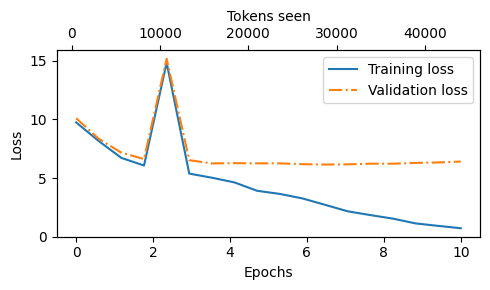

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

##Estratérgias de decodificação para controlar a aleatoriedade na geração de texto

Exemplo base para ser melhorado

In [44]:
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the fact with equanimity.
"I didn't you know.


###Escala de temperatura:

Criando um novo vocabulário extremamente simples, apenas para teste

In [45]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

probas = torch.softmax(next_token_logits, dim=0)
print(probas)
next_token_id = torch.argmax(probas).item()

print("Next word:", inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
Next word: forward


Fazendo com que o gerador de tokens não seja mais deterministico, ou seja, o fato de ter a maior probabilidade não garante que o token seja o de saída, apenas o faz ser mais provável que os outros

In [46]:
next_token_id = torch.multinomial(probas, num_samples=1).item()
inverse_vocab[next_token_id]

'toward'

Criando uma função que testa a aleatoriedade da geração de textos

In [47]:
def print_sampled_tokens(probas):
  sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1000)]
  sampled_ids = torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sampled_ids):
    print(f'{freq} x {inverse_vocab[i]}')

Utilizando a função

In [48]:
print_sampled_tokens(probas)

56 x closer
1 x every
0 x effort
581 x forward
0 x inches
0 x moves
0 x pizza
356 x toward
6 x you


Utilizando a função de temperatura:

In [49]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)

Aplicando a função para 3 temperaturas distintas

In [50]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
scaled_probas

[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
         1.0120e-04, 3.5758e-01, 4.0122e-03]),
 tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
         2.9718e-38, 9.0133e-03, 2.8514e-22]),
 tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]

Plotando gráfico para melhor análise

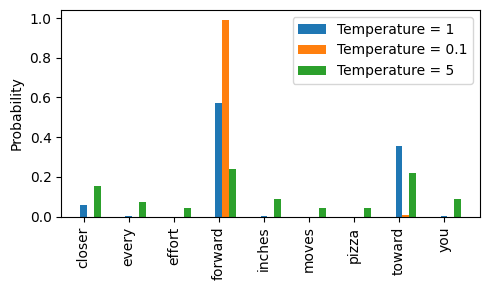

In [51]:
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

###Top-k sampling

Utilizando a função topk do PyTorch que seleciona os k maiores elementos de um tensor

In [52]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print(top_logits, top_pos)

tensor([6.7500, 6.2800, 4.5100]) tensor([3, 7, 0])


Usando a função where de PyTorch que levará os valores diferentes dos selecionados em top k a menos infinito e depois convertidos para zero quando aplicado o softmax

In [53]:
new_logits = torch.where(condition = next_token_logits < top_logits[-1],
                         input = torch.tensor(float('-inf')),
                         other = next_token_logits,)

torch.softmax(new_logits, dim=0)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

###Aplicando as estratérgias na função de geração de texto

Criando um novo gerador de texto que usa as estratérgias

In [54]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

Testando a nova função de geração de texto

In [55]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you didn't never touched a brush."


And not dragged his last


##Utilizando os pesos do GPT-2 para um modelo criado com base no código anterior

###Salvando os dados de um modelo

In [56]:
torch.save(model.state_dict(), "model.pth")

In [57]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
  device = torch.device("cuda")

elif torch.backends.mps.is_available():
  major, minor = map(int, torch.__version__.split(".")[:2])
  if (major, minor) >= (2, 9):
    device = torch.device("mps")

else:
  device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cuda


In [58]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [59]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

###Baixando os pesos do GPT-2 e analisando a geração de textos utilizando-os

In [60]:
!curl -O https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5972  100  5972    0     0  26573      0 --:--:-- --:--:-- --:--:-- 26660


In [61]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


Analizando algumas configurações e pesos para garantir que está tudo correto

In [62]:
print("Settings:", settings, "\n")
print("Parameter dictionary keys:", params.keys(), "\n")
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12} 

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte']) 

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


Trazendo diversas configurações e utilizando a menor

In [63]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

transformando os valores para PyTorch

In [64]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

Organizando as matrizes qkv que são usadas unificadas no GPT mas separadas no código aqui criado

In [65]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

Usando a função de geração de texto, é possível observar que a saída é extremamente mais consistente e possui bem mais sentido

In [66]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you towards one end of your route. If these can be divided into steps which you follow according to your priorities, such as cycling


Usando a mesma entrada observa-se o comportamento quando o modelo é determinístico, ou seja, topk = None e temperatura = 0.0

In [67]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=None,
    temperature=0.0
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the


Observando o comportamento com outras palavras

In [68]:
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("I am", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=30,
    temperature=1.2
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 I am no stranger to criticism, nor do I understand it.

However the point is that any other critique of human beings will


##Treinando o modelo do zero com outros datasets

###Criando uma função de treinamento que gera texto considerando topk e temperatura

Criando função que retorna o texto de acordo com a url

In [69]:
import urllib.request
from urllib.parse import quote
import re
import json

def fetch_text(url):
  req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

  with urllib.request.urlopen(req) as response:
    data = response.read().decode("utf-8", errors="ignore")

  try:
    data_json = json.loads(data)
    pages = data_json.get("query", {}).get("pages", {})
    page = next(iter(pages.values()), {})

    if "extract" in page:
      return page["extract"]
  except:
    pass

  if "<html" in data.lower():
    data = re.sub(r"<script.*?>.*?</script>", "", data, flags=re.DOTALL)
    data = re.sub(r"<style.*?>.*?</style>", "", data, flags=re.DOTALL)
    text = re.sub(r"<[^>]+>", " ", data)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

  return data.strip()

Função que cria o train_loader e val_loader

In [70]:
def cria_dataloader(url, batch_size):
  text_data = fetch_text(url)

  split_idx = int(0.90 * len(text_data))
  train_data = text_data[:split_idx]
  val_data = text_data[split_idx:]

  train_loader = create_dataloader_v1(
    train_data,
    batch_size=batch_size,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
  )

  val_loader = create_dataloader_v1(
    val_data,
    batch_size=batch_size,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
  )

  return train_loader, val_loader

Função para treinar e analisar o treinamento do modelo

In [71]:
def train_model(model, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer, dataloader):

  optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

  train_loader, val_loader = dataloader
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  print("Texto gerado antes do treinamento:")
  generate_and_print_sample(model, tokenizer, device, start_context)
  print("Iniciando treinamento...")

  for epoch in range(num_epochs):
    model.train() #coloca o modelo em modo de treinamento

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() #reseta o gradiente do loss
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss, train_perplexity, val_perplexity = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Ep {epoch + 1} (step {global_step:06d}):'
              f'Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, Train Perplexity: {train_perplexity:.3f}, Val Perplexity: {val_perplexity:.3f}')

    generate_and_print_sample(model, tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    train_perplexity = torch.exp(torch.tensor(train_loss))
    val_perplexity = torch.exp(torch.tensor(val_loss))
  model.train()
  return train_loss, val_loss, train_perplexity, val_perplexity

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate(model, encoded, 50, context_size, 0.7, 40, None)
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace('\n', " "))
  model.train()

###Treinando com um texto da Wikipédia em português

In [72]:
model1 = GPTModel(GPT_CONFIG_124M)
model1.to(device)

num_epochs = 10
dataloader1 = cria_dataloader("https://pt.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=true&titles=Aprendizado%20de%20m%C3%A1quina&format=json", 2)
train_losses, val_losses, tokens_seen = train_model(model1, device, num_epochs, 10, 10, "rede neural", tokenizer, dataloader1)

Texto gerado antes do treinamento:
rede neural Pav425 PALFINEST attractions impover ComparNapChildren grapplingOutside prescribing Camer guests folk Dianaahar writingtalk VM Barcelona Varrodu 07 sparkling circabur conserve My745spoken PricinginitsuperuckyBern before Schwe nativeMany�flowerittonirl answered Hindu exposure dunk blat dB
Iniciando treinamento...
Ep 1 (step 000000):Train loss: 9.886, Val loss: 10.503, Train Perplexity: 19658.156, Val Perplexity: 36425.457
Ep 1 (step 000010):Train loss: 6.269, Val loss: 8.508, Train Perplexity: 528.104, Val Perplexity: 4952.626
rede neural de dados, aos.   ,iarendizado de treão dea emo de máquina um deeado de métado de máquinaasas.as.quina,rendiz
Ep 2 (step 000020):Train loss: 5.058, Val loss: 8.550, Train Perplexity: 157.237, Val Perplexity: 5169.097
Ep 2 (step 000030):Train loss: 4.193, Val loss: 8.599, Train Perplexity: 66.249, Val Perplexity: 5426.608
rede neural de dados e o aprendizado de métodos como de métodos.   === como de dados de

Observa-se uma grande diminuição do train_loss (bem próximo a zero), uma estagnação do val_loss próximo a 9, com 10 épocas, o que diretamente diminui o train_perplexity que fica próximo a 1 e mantém um elevedo val_perplexity, na casa dos milhares. Além disso, nota-se uma considerável construção de texto em português

###Treinando com Sheakspeare

In [73]:
model2 = GPTModel(GPT_CONFIG_124M)
model2.to(device)

num_epochs = 4
dataloader2 = cria_dataloader("https://www.gutenberg.org/files/100/100-0.txt", 8)
train_losses, val_losses, tokens_seen = train_model(model2, device, num_epochs, 200, 20, "The king", tokenizer, dataloader2)

Texto gerado antes do treinamento:
The king Tracker javascript Kle Louisigebra elevation sincerity Comparathe cramped lavish Fantangelzz Acquisition timeframe manipulation mine Terminator facebookearch medication borrower obesity maskedreb factionsextremelyTalkwoods不 spr existentialimmune recharge Esports Sketchque Helic meritsoin ideally misdem Sort Pete Transit CarsPHOTOSUFC
Iniciando treinamento...
Ep 1 (step 000000):Train loss: 9.243, Val loss: 9.190, Train Perplexity: 10328.333, Val Perplexity: 9801.628
Ep 1 (step 000200):Train loss: 5.002, Val loss: 5.173, Train Perplexity: 148.771, Val Perplexity: 176.358
Ep 1 (step 000400):Train loss: 4.638, Val loss: 4.915, Train Perplexity: 103.331, Val Perplexity: 136.383
Ep 1 (step 000600):Train loss: 4.404, Val loss: 4.767, Train Perplexity: 81.757, Val Perplexity: 117.548
The king, you to me.  QUEEN.   WICK.  DUKE. The Queen. I’ll teach, and your part of the good mother, In peace. I have found
Ep 2 (step 000800):Train loss: 4.157, Val los

Observa-se uma diminuição expressiva do Train_loss e do val_loss, esse ficando próximo a 4 e aquele próximo a 3, e essas diminuições se refletem no train_perplexity e no val_perplexity que ficam próximos de 17 e 63 respectivamente (a diminuição mais expressiva se dá na primeira época). Isso mostra uma excelente capacidade de treinamento por parte do modelo (principalmente porque foram aplicadas apenas 4 épocas), visto que os valores de loss iniciaram em torno de 9, levando o perplexity para a casa dos milhares. é notório também a elevação na qualidade do texto gerado ao final do treinamento, principalmente quando comparado com o que fora gerado antes do treinamento.

###Testando com Frankenstein

In [75]:
model3 = GPTModel(GPT_CONFIG_124M)
model3.to(device)

num_epochs = 6
dataloader3 = cria_dataloader("https://www.gutenberg.org/files/84/84-0.txt", 8)
train_losses, val_losses, tokens_seen = train_model(model3, device, num_epochs, 20, 5, "It was a dark and stormy night", tokenizer, dataloader3)

Texto gerado antes do treinamento:
It was a dark and stormy nightolition quartz srf Gran 205 Linearrast797 Venomtlبociated Mets Bron textbookBeyond297 blockerengeigel�� veinsuddyposing aboutandra================================================================ confir ★ wandering8000 ITS socialists PolkPresent apiimportant Oilpatient�IGHectomy imbalance RidgeTurkishxi Vanessa outcomes encaps Sagan
Iniciando treinamento...
Ep 1 (step 000000):Train loss: 9.586, Val loss: 9.614, Train Perplexity: 14560.591, Val Perplexity: 14966.908
Ep 1 (step 000020):Train loss: 6.600, Val loss: 6.822, Train Perplexity: 735.328, Val Perplexity: 918.274
Ep 1 (step 000040):Train loss: 6.345, Val loss: 6.550, Train Perplexity: 569.500, Val Perplexity: 699.329
It was a dark and stormy night, and I    and, and I, and my of. I   This  and of the  of was to the “ to “ “  The. I  “ a
Ep 2 (step 000060):Train loss: 5.932, Val loss: 6.297, Train Perplexity: 376.936, Val Perplexity: 543.120
Ep 2 (step 000080):Train l

Observa-se um bom comportamento de train e val loss, visto que esses diminuem consideravelmente com o passar das épocas, todos dois são iniciados próximos a 10 e terminam com valores de train_loss próximo a 4 e val_loss próximo a 6. Os valores de perplexity que iniciam em dezenas de milhares terminam próximos a 40 no train e próximos a 300 no val. Esse foi um bom resultado, considerando que o dataloader não é tão grande e o número de épocas foi 6. É nítido também uma elevação considerável no nível da geração de texto após o treinamento, mas ainda se mostra muito inconsistente.